In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("yield_df.csv")

print("First 5 rows:")
print(df.head())

First 5 rows:
   Unnamed: 0     Area         Item  Year  hg/ha_yield  \
0           0  Albania        Maize  1990        36613   
1           1  Albania     Potatoes  1990        66667   
2           2  Albania  Rice, paddy  1990        23333   
3           3  Albania      Sorghum  1990        12500   
4           4  Albania     Soybeans  1990         7000   

   average_rain_fall_mm_per_year  pesticides_tonnes  avg_temp  
0                           1485              121.0     16.37  
1                           1485              121.0     16.37  
2                           1485              121.0     16.37  
3                           1485              121.0     16.37  
4                           1485              121.0     16.37  


In [3]:
# Remove unwanted index column if present
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

In [4]:
# Check column names
print("\nColumns in dataset:")
print(df.columns)




Columns in dataset:
Index(['Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year',
       'pesticides_tonnes', 'avg_temp'],
      dtype='object')


In [5]:
df = pd.get_dummies(df, columns=['Area', 'Item'], drop_first=True)


In [6]:
X = df.drop('hg/ha_yield', axis=1)
y = df['hg/ha_yield']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)


In [8]:
rf_model = RandomForestRegressor(
    n_estimators=300,      # number of trees
    max_depth=None,        # no depth limit
    random_state=42
)


In [9]:

rf_model.fit(X_train, y_train)


,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [10]:
y_pred = rf_model.predict(X_test)


In [11]:

print("\nModel Performance:")

print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))


Model Performance:
Mean Absolute Error: 3626.0641823045753
Mean Squared Error: 95862401.51273018
Root Mean Squared Error: 9790.934659813136
R2 Score: 0.9870668513532233


In [12]:
new_data=pd.DataFrame({
    'Year':[2022],
    'average_rain_fall_mm_per_year':[1200],
    'pesticides_tonnes':[1500],
    'avg_temp':[25],
    'Area':['Albania'],
    'Item':['Maize']})

In [13]:
new_data=pd.get_dummies(new_data)
new_data=new_data.reindex(columns=X.columns,fill_value=0)
prediction=rf_model.predict(new_data)
print("Predicted Yield: ",prediction[0] )

Predicted Yield:  19892.236666666668


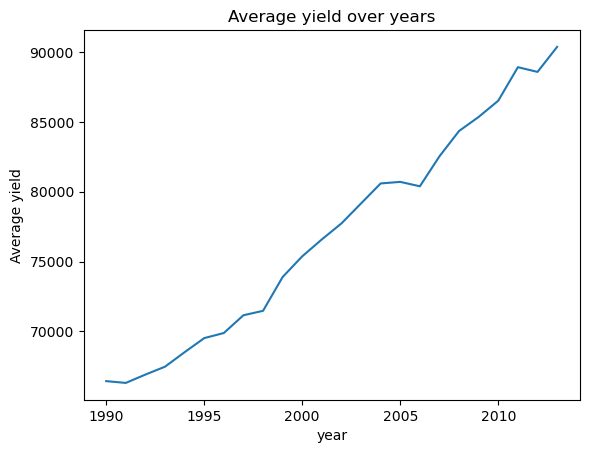

In [18]:
df.groupby('Year')['hg/ha_yield'].mean().plot()
plt.title("Average yield over years")
plt.xlabel("year")
plt.ylabel("Average yield")
plt.show()

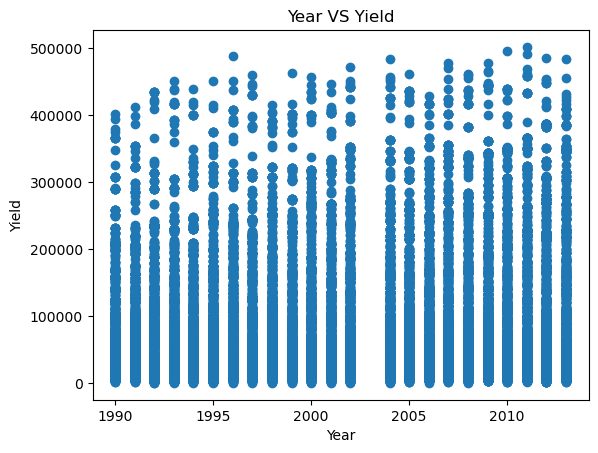

In [19]:
plt.scatter(df['Year'],df['hg/ha_yield'])
plt.xlabel("Year")
plt.ylabel("Yield")
plt.title("Year VS Yield")
plt.show()

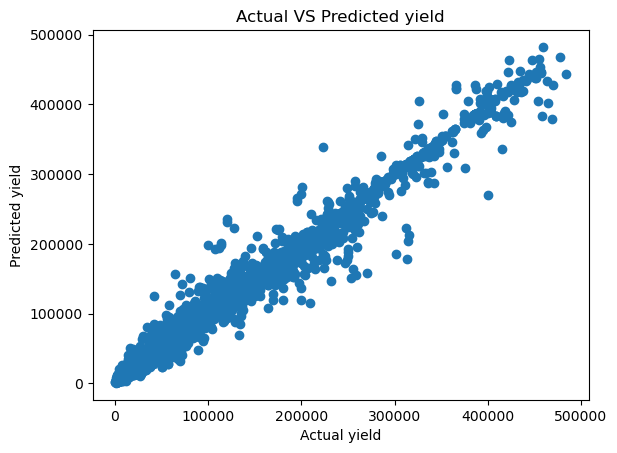

In [20]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual yield")
plt.ylabel("Predicted yield")
plt.title("Actual VS Predicted yield")
plt.show()

In [22]:
import pickle

# Save model
with open('crop_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)